# HAP trends: coal and biomass

A basic analysis of household air-pollution exposure from coal/charcoal, wood, agricultural residue, and dung from 1990 to 2023.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
data_dir = root / "data" / "IHME_GBD_2023_AIR_POLLUTION_1990_2023_HAP"
files = sorted(data_dir.glob("*_HAP_[12][0-9][0-9][0-9]_Y*.CSV"))
len(files), files[0].name, files[-1].name

(34,
 'IHME_GBD_2023_AIR_POLLUTION_1990_2023_HAP_1990_Y2025M02D13.CSV',
 'IHME_GBD_2023_AIR_POLLUTION_1990_2023_HAP_2023_Y2025M02D13.CSV')

In [3]:
raw = pd.concat((pd.read_csv(f, low_memory=False) for f in files), ignore_index=True)
raw.shape

(252280, 18)

In [4]:
fuels = {394: "Coal and charcoal", 395: "Wood", 396: "Agricultural residue", 397: "Dung"}
panel = raw.query("measure_id == 18 and sex_id == 3 and age_group_id == 22 and rei_id in @fuels").copy()
panel["fuel"] = panel["rei_id"].map(fuels)
panel["mean_pct"] = panel["mean"] * 100

In [5]:
pd.Series({
    "annual files": len(files), "panel rows": len(panel),
    "years": panel.year_id.nunique(), "locations": panel.location_id.nunique(),
    "duplicate keys": panel.duplicated(["location_id", "year_id", "rei_id"]).sum()
})

annual files          34
panel rows        100912
years                 34
locations            742
duplicate keys         0
dtype: int64

The analysis uses the proportion measure for both sexes and all ages. Fuel categories remain separate rather than being summed.

In [6]:
global_trend = panel.loc[panel.location_id.eq(1)].pivot(
    index="year_id", columns="fuel", values="mean_pct"
)
global_trend.head()

fuel,Agricultural residue,Coal and charcoal,Dung,Wood
year_id,,,,
1990,2.186465,9.661923,2.002785,43.722053
1991,2.257680,9.621099,1.993487,43.199666
1992,2.332270,9.543443,1.988203,42.698708
1993,2.396226,9.461782,1.998756,42.198037
1994,2.462590,9.348321,2.018640,41.692030


In [7]:
change = pd.DataFrame({"1990 (%)": global_trend.loc[1990], "2023 (%)": global_trend.loc[2023]})
change["change (pp)"] = change["2023 (%)"] - change["1990 (%)"]
change.round(2)

,1990 (%),2023 (%),change (pp)
fuel,,,
Agricultural residue,2.19,2.12,-0.06
Coal and charcoal,9.66,5.17,-4.49
Dung,2.00,1.29,-0.71
Wood,43.72,20.46,-23.26


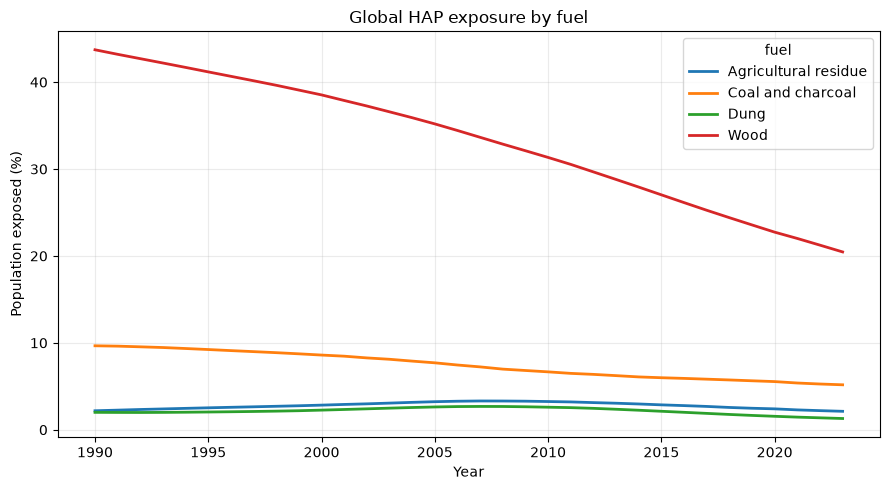

In [8]:
ax = global_trend.plot(figsize=(9, 5), linewidth=2)
ax.set(title="Global HAP exposure by fuel", xlabel="Year", ylabel="Population exposed (%)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## HAP-only panel

The table below keeps one row per location and year. Match it to country-level energy data before estimating coal and biomass coefficients.

In [9]:
model_panel = panel.pivot(
    index=["location_id", "ihme_loc_id", "location_name", "year_id"],
    columns="fuel", values="mean"
).reset_index()
model_panel.head()

fuel,location_id,ihme_loc_id,location_name,year_id,Agricultural residue,Coal and charcoal,Dung,Wood
0,1,G,Global,1990,0.021865,0.096619,0.020028,0.437221
1,1,G,Global,1991,0.022577,0.096211,0.019935,0.431997
2,1,G,Global,1992,0.023323,0.095434,0.019882,0.426987
3,1,G,Global,1993,0.023962,0.094618,0.019988,0.421980
4,1,G,Global,1994,0.024626,0.093483,0.020186,0.416920


## Linked energy and biomass panel

Run `hap_energy_merge.ipynb` first. It creates the processed country-year panel loaded below.

In [10]:
merged_path = root / "data" / "processed" / "hap_energy_biomass_panel.csv"
merged = pd.read_csv(merged_path)
merged.shape

(6936, 34)

In [11]:
pd.Series({
    "country-years": len(merged),
    "with residential coal": merged.res_coa_ktoe.notna().sum(),
    "with residential biomass": merged.res_bio_ktoe.notna().sum(),
    "with coal and biomass": (merged.res_coa_ktoe.notna() & merged.res_bio_ktoe.notna()).sum(),
})

country-years               6936
with residential coal       4105
with residential biomass    4105
with coal and biomass       4105
dtype: int64

In [12]:
linked_columns = [
    "iso3", "location_name", "year", "hap_coal_charcoal", "hap_wood",
    "hap_residue", "hap_dung", "res_coa_ktoe", "res_bio_ktoe"
]
merged[linked_columns].dropna(subset=["res_coa_ktoe", "res_bio_ktoe"]).head()

,iso3,location_name,year,hap_coal_charcoal,hap_wood,hap_residue,hap_dung,res_coa_ktoe,res_bio_ktoe
34,AGO,Angola,1990,0.398368,0.599833,0.002364,0.000073,0.0,3115.4390
35,AGO,Angola,1991,0.405176,0.583374,0.002324,0.000073,0.0,3187.8332
36,AGO,Angola,1992,0.411514,0.566786,0.002289,0.000072,0.0,3262.3483
37,AGO,Angola,1993,0.418174,0.549100,0.002272,0.000072,0.0,3338.2249
38,AGO,Angola,1994,0.423552,0.531964,0.002262,0.000072,0.0,3403.3439


Energy values are national totals in ktoe. Normalize them by population or use residential energy shares before estimating coefficients.